# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import numpy as np
import pandas as pd
import s3fs, os
import boto3
import pyarrow.parquet as pq
from matplotlib import pyplot as plt
from scipy.sparse import csr_matrix
from dotenv import load_dotenv

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [ ]:
tracks = pd.read_parquet("data/tracks.parquet")

In [3]:
interactions = pd.read_parquet("data/interactions.parquet")

In [2]:
catalog_names = pd.read_parquet("data/catalog_names.parquet")

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [6]:
tracks = tracks[tracks["albums"].apply(len) > 0]
tracks = tracks[tracks["artists"].apply(len) > 0]
tracks = tracks[tracks["genres"].apply(len) > 0]

In [7]:
interactions = interactions[interactions["track_id"].isin(tracks["track_id"])]

# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

Размерность датасета tracks (980977, 4)

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

In [6]:
user_track_count = interactions.groupby("user_id")["track_id"].count()

In [6]:
user_track_count.describe().apply(lambda x : str(x))

count             1373221.0
mean     162.12241001266366
std       351.2846250431907
min                     1.0
25%                    23.0
50%                    55.0
75%                   154.0
max                 16637.0
Name: item_id, dtype: object

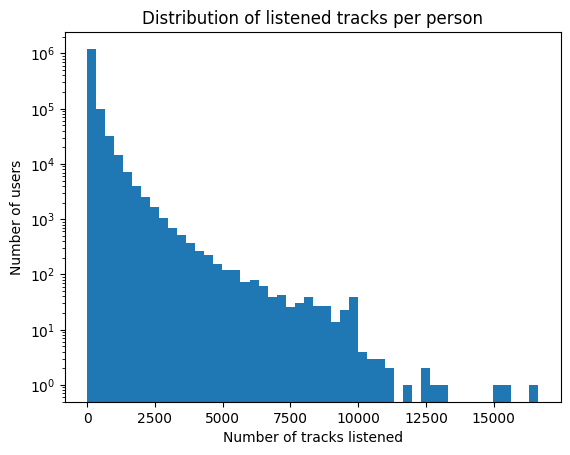

In [7]:
plt.hist(user_track_count, bins=50, log=True)
plt.xlabel("Number of tracks listened")
plt.ylabel("Number of users")
plt.title("Distribution of listened tracks per person")
plt.show()

Очень много пользователей слушают мало треков

Очень мало ползователей слушают много треков

Наиболее популярные треки

In [8]:
track_popularity = interactions.groupby("track_id")["user_id"].count()
track_popularity.describe()

count    1000000.000000
mean         222.629898
std         1369.930708
min            5.000000
25%            9.000000
50%           19.000000
75%           67.000000
max       111062.000000
Name: user_id, dtype: float64

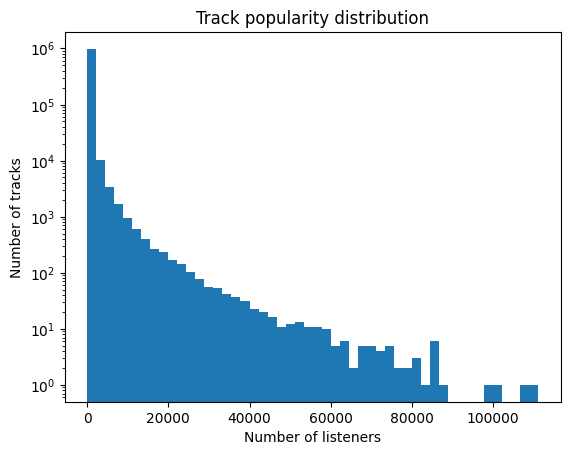

In [69]:
plt.hist(track_popularity, bins=50, log=True)
plt.xlabel("Number of listeners")
plt.ylabel("Number of tracks")
plt.title("Track popularity distribution")
plt.show()

Наиболее популярные жанры

In [9]:
interactions = interactions.merge(tracks[["track_id", "genres"]], on="track_id", how="left")

Получаем треки которые есть в interactions

In [10]:
track_filtered = tracks[tracks["track_id"].isin(track_popularity.index)].copy()

In [11]:
all_genres = sorted({genre for genres in track_filtered["genres"] for genre in genres})

In [12]:
genres_to_idx = {genre: idx for idx, genre in enumerate(all_genres)}
idx_to_genres = {idx: genre for genre, idx in genres_to_idx.items()}

In [14]:
track_ids = track_filtered["track_id"].unique()
track_to_idx = {track_id: idx for idx, track_id in enumerate(track_ids)}
idx_to_track = {idx: track_id for track_id, idx in track_to_idx.items()}

In [17]:
def track_genres_csr_matrix(tracks, track_to_idx, genres_to_idx):
    row_indices = []
    col_indices = []
    data = []
    for _, row in tracks[["track_id", "genres"]].iterrows():
        track_id = row["track_id"]
        genres = row["genres"]
        track_idx = track_to_idx[track_id]

        for genre in genres:
            genre_idx = genres_to_idx[genre]
            row_indices.append(track_idx)
            col_indices.append(genre_idx)
            data.append(1)
    
    track_genre_matrix = csr_matrix((data, (row_indices, col_indices)), shape=(len(track_to_idx), len(genres_to_idx)), dtype="int8")

    return track_genre_matrix


In [18]:
track_genre_matrix = track_genres_csr_matrix(track_filtered, track_to_idx, genres_to_idx)

In [19]:
def gen_popular_vector(track_genre_matrix):
    track_popularity_vector = np.zeros(len(track_to_idx), dtype=np.int64)
    for tr_id, count in track_popularity.items():
        try:
            tr_idx = track_to_idx[tr_id]
            track_popularity_vector[tr_idx] = count
        except KeyError:
            track_popularity_vector[tr_idx] = 0
    
    genre_popularity_vector = track_genre_matrix.T @ track_popularity_vector
    return genre_popularity_vector
    

In [20]:
genre_popularity_vector = gen_popular_vector(track_genre_matrix)

In [21]:
genre_popularity = pd.DataFrame({
    "genre": all_genres,
    "popularity": genre_popularity_vector
}).sort_values("popularity", ascending=False)

In [ ]:
interactions.drop(columns=["genres"], inplace=True)

In [22]:
genre_popularity.head(10)

,genre,popularity
10,11,54729828
70,75,37153325
89,102,30944628
19,20,26066023
2,3,24854696
63,68,19837411
15,16,16080931
1,2,13114074
13,14,12691915
42,47,12399886


10 наиболее популярных жанров

Треки, которые никто не прослушал

In [24]:
tracks[~(tracks["track_id"].isin(interactions["track_id"]))].size

0

Все треки были прослушаны хотя бы один раз.

# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [10]:
items = tracks.copy()
events = interactions.copy()

In [11]:
del tracks
del interactions

In [12]:
items = items.rename(columns={"track_id": "item_id"})
events = events.rename(columns={"track_id": "item_id", "track_seq": "item_seq"})

In [17]:
catalog_names = catalog_names.rename(columns={"id": "item_id"})

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [3]:
load_dotenv()
access_key = os.getenv("AWS_ACCESS_KEY_ID")
secret_key = os.getenv("AWS_SECRET_ACCESS_KEY")
endpoint_url = os.getenv("S3_ENDPOINT_URL")
bucket = os.getenv("S3_BUCKET")

In [14]:
events.to_parquet(f"s3://{bucket}/recsys/data/events.parquet", engine="pyarrow", index=False, storage_options={
        "key": access_key,
        "secret": secret_key,
        "client_kwargs": {
            "endpoint_url": endpoint_url
        }
    })

In [41]:
items.to_parquet(f"s3://{bucket}/recsys/data/items.parquet", engine="pyarrow", index=False, storage_options={
        "key": access_key,
        "secret": secret_key,
        "client_kwargs": {
            "endpoint_url": endpoint_url
        }
    })

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [42]:
del track_popularity, user_track_count, gen_popular_vector, genre_popularity, track_filtered, track_genre_matrix

Для продолжения перезапустите kernel.

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [15]:
s3 = boto3.client("s3", endpoint_url=endpoint_url, aws_access_key_id=access_key, aws_secret_access_key=secret_key)

In [16]:
s3.download_file(bucket, "recsys/data/events.parquet", "data/events.parquet")

In [4]:
table = pq.read_table("data/events.parquet", columns=["user_id", "item_id", "started_at"])

In [9]:
events = table.to_pandas()

In [10]:
items = pd.read_parquet(f"s3://{bucket}/recsys/data/items.parquet", engine="pyarrow", storage_options={
        "key": access_key,
        "secret": secret_key,
        "client_kwargs": {
            "endpoint_url": endpoint_url
        }
    })

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [11]:
split_point = pd.to_datetime("2022-12-16")
split_idx = events["started_at"] < split_point

In [12]:
events_train = events[split_idx]
events_test = events[~split_idx]

# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [72]:
top_pop_start_date = pd.to_datetime("2022-09-01").date()
item_popularity = (events_train.query("started_at >= @top_pop_start_date").groupby("item_id").agg(listen_count=("item_id", "count")).reset_index().sort_values(by="listen_count", ascending=False))

In [73]:
top_10_popular_items = item_popularity[:10].merge(catalog_names[["item_id", "type", "name"]], on="item_id", how="left")

In [27]:
top_10_popular_items.to_parquet(f"s3://{bucket}/recsys/recommendations/top_popular.parquet", engine="pyarrow", storage_options={
        "key": access_key,
        "secret": secret_key,
        "client_kwargs": {
            "endpoint_url": endpoint_url
        }
})

In [7]:
top_10_popular_items = pd.read_parquet(f"s3://{bucket}/recsys/recommendations/top_popular.parquet", engine="pyarrow", storage_options={
    "key": access_key,
    "secret": secret_key,
    "client_kwargs": {
        "endpoint_url": endpoint_url
    }
})

# Персональные

Рассчитаем персональные рекомендации.

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
train_interactions = (events_train.groupby(["user_id", "item_id"], as_index=False).size().rename(columns={"size": "weight"}))

In [19]:
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

In [20]:
user_encoder.fit(train_interactions["user_id"])
item_encoder.fit(train_interactions["item_id"])

LabelEncoder()

In [21]:
train_interactions["user_id_enc"] = user_encoder.transform(train_interactions["user_id"])
train_interactions["item_id_enc"] = item_encoder.transform(train_interactions["item_id"])

In [22]:
user_item_matrix = csr_matrix((train_interactions["weight"].astype(float), (train_interactions["user_id_enc"], train_interactions["item_id_enc"])))

In [23]:
from implicit.als import AlternatingLeastSquares

/home/mle-user/mle-project-sprint-4/.venv_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
model = AlternatingLeastSquares(
    factors=50,
    regularization=0.05,
    iterations=10,
    random_state=42
)

/home/mle-user/mle-project-sprint-4/.venv_recsys_start/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


In [25]:
model.fit(user_item_matrix)

100%|██████████| 10/10 [08:04<00:00, 48.40s/it]


In [26]:
def get_recommendations_als(user_item_matrix, model, user_id, user_encoder, item_encoder, include_seen=True, n=5):
    user_id_enc = user_encoder.transform(user_id)[0]
    recommendations = model.recommend(user_id_enc,
                                      user_item_matrix[user_id_enc],
                                      filter_already_liked_items=include_seen,
                                      N=n)
    recommendations = pd.DataFrame({"item_id_enc": recommendations[0], "score": recommendations[1]})
    recommendations["item_id"] = item_encoder.inverse_transform(recommendations["item_id_enc"])

    return recommendations

In [27]:
events_test = events_test[events_test["user_id"].isin(user_encoder.classes_) & events_test["item_id"].isin(item_encoder.classes_)].copy()

In [45]:
user_sample = events_test.sample()

In [46]:
user_sample

,user_id,item_id,started_at
186732458,1155725,51320248,2022-12-21


In [106]:
recommendations = get_recommendations_als(user_item_matrix, model, user_sample["user_id"], user_encoder, item_encoder, False, 10)

In [107]:
recommendations = recommendations.drop(columns=["item_id_enc"])[["item_id", "score"]]

In [108]:
recommendations["user_id"] = user_sample["user_id"].iloc[0]

In [109]:
recommendations = recommendations.merge(catalog_names.rename(columns={"id": "item_id"}), on="item_id")

In [111]:
recommendations.to_parquet(f"s3://{bucket}/recsys/recommendations/personal_als.parquet", engine="pyarrow", index=False, storage_options={
        "key": access_key,
        "secret": secret_key,
        "client_kwargs": {
            "endpoint_url": endpoint_url
        }
    })

In [13]:
recommendations = pd.read_parquet(f"s3://{bucket}/recsys/recommendations/personal_als.parquet", engine="pyarrow", storage_options={
    "key": access_key,
    "secret": secret_key,
    "client_kwargs": {
        "endpoint_url": endpoint_url
    }
})

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [77]:
item_id_enc = item_encoder.transform([user_sample["item_id"]])
similar_items = model.similar_items(item_id_enc)

/home/mle-user/mle-project-sprint-4/.venv_recsys_start/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [78]:
similar_items = pd.DataFrame({"item_id_enc": similar_items[0].ravel(), "score": similar_items[1].ravel()})

In [79]:
similar_items["item_id"] = item_encoder.inverse_transform(similar_items["item_id_enc"])

In [80]:
similar_items = similar_items.drop(columns=["item_id_enc"])[["item_id", "score"]]

In [82]:
similar_items = similar_items.merge(catalog_names.rename(columns={"id": "item_id"}), on="item_id")

In [30]:
similar_items["user_id"] = user_sample["user_id"].iloc[0]

In [31]:
similar_items.to_parquet(f"s3://{bucket}/recsys/recommendations/similar.parquet", engine="pyarrow", index=False, storage_options={
        "key": access_key,
        "secret": secret_key,
        "client_kwargs": {
            "endpoint_url": endpoint_url
        }
    })

In [14]:
similar_items = pd.read_parquet(f"s3://{bucket}/recsys/recommendations/similar.parquet", engine="pyarrow", storage_options={
    "key": access_key,
    "secret": secret_key,
    "client_kwargs": {
        "endpoint_url": endpoint_url
    }
})

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [25]:
user_sample = events_test[events_test["user_id"].isin(recommendations["user_id"])]

In [20]:
from sklearn.preprocessing import MinMaxScaler

In [17]:
top_10_popular_items = top_10_popular_items.rename(columns={"listen_count": "popularity_score"})

In [21]:
encoder = MinMaxScaler()

In [22]:
top_10_popular_items["popularity_score"] = encoder.fit_transform(top_10_popular_items["popularity_score"].values.reshape(-1, 1))

In [26]:
top_10_popular_items["user_id"] = user_sample["user_id"].iloc[0]

In [37]:
similar_items = similar_items.rename(columns={"score": "similarity_score"})

In [131]:
similar_items["user_id"] = user_sample["user_id"].iloc[0]

In [36]:
recommendations = recommendations.rename(columns={"score": "als_score",})

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [40]:
base_recommendations = pd.concat([recommendations, similar_items, top_10_popular_items]).groupby(["user_id", "item_id"], as_index=False).max()

In [42]:
base_recommendations = base_recommendations[["user_id", "item_id", "als_score", "similarity_score", "popularity_score"]]

In [43]:
base_recommendations["als_score"] = base_recommendations["als_score"].fillna(0)
base_recommendations["similarity_score"] = base_recommendations["similarity_score"].fillna(0)
base_recommendations["popularity_score"] = base_recommendations["popularity_score"].fillna(0)

/tmp/ipykernel_1740/86525355.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_recommendations["als_score"] = base_recommendations["als_score"].fillna(0)
/tmp/ipykernel_1740/86525355.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_recommendations["similarity_score"] = base_recommendations["similarity_score"].fillna(0)
/tmp/ipykernel_1740/86525355.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [45]:
base_recommendations.to_parquet(f"s3://{bucket}/recsys/recommendations/recommendations.parquet", engine="pyarrow", index=False, storage_options={
        "key": access_key,
        "secret": secret_key,
        "client_kwargs": {
            "endpoint_url": endpoint_url
        }
    })

In [ ]:
base_recommendations = pd.read_parquet(f"s3://{bucket}/recsys/recommendations/recommendations.parquet", engine="pyarrow", storage_options={
    "key": access_key,
    "secret": secret_key,
    "client_kwargs": {
        "endpoint_url": endpoint_url
    }
})

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [46]:
def process_events_recs_for_binary_metrics(events_train, events_test, recs, top_k=None):

    """
    размечает пары <user_id, item_id> для общего множества пользователей признаками
    - gt (ground truth)
    - pr (prediction)
    top_k: расчёт ведётся только для top k-рекомендаций
    """

    events_test["gt"] = True
    common_users = set(events_test["user_id"]) & set(recs["user_id"])

    print(f"Common users: {len(common_users)}")
    
    events_for_common_users = events_test[events_test["user_id"].isin(common_users)].copy()
    recs_for_common_users = recs[recs["user_id"].isin(common_users)].copy()

    recs_for_common_users = recs_for_common_users.sort_values(["user_id", "score"], ascending=[True, False])

    # оставляет только те item_id, которые были в events_train, 
    # т. к. модель не имела никакой возможности давать рекомендации для новых айтемов
    events_for_common_users = events_for_common_users[events_for_common_users["item_id"].isin(events_train["item_id"].unique())]

    if top_k is not None:
        recs_for_common_users = recs_for_common_users.groupby("user_id").head(top_k)
    
    events_recs_common = events_for_common_users[["user_id", "item_id", "gt"]].merge(
        recs_for_common_users[["user_id", "item_id", "score"]], 
        on=["user_id", "item_id"], how="outer")    

    events_recs_common["gt"] = events_recs_common["gt"].fillna(False)
    events_recs_common["pr"] = ~events_recs_common["score"].isnull()
    
    events_recs_common["tp"] = events_recs_common["gt"] & events_recs_common["pr"]
    events_recs_common["fp"] = ~events_recs_common["gt"] & events_recs_common["pr"]
    events_recs_common["fn"] = events_recs_common["gt"] & ~events_recs_common["pr"]

    return events_recs_common

In [48]:
events_recs_for_binary_metrics = process_events_recs_for_binary_metrics(
  events_train,
    events_test, 
    recommendations.rename(columns={"als_score": "score"}), 
    top_k=10) 

/tmp/ipykernel_1740/3166051426.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_test["gt"] = True


Common users: 1


In [49]:
def compute_cls_metrics(events_recs_for_binary_metric):
    groupper = events_recs_for_binary_metric.groupby("user_id")

    precision = groupper["tp"].sum() / (groupper["tp"].sum()+groupper["fp"].sum())
    precision = precision.fillna(0).mean()

    recall = groupper["tp"].sum() / (groupper["tp"].sum()+groupper["fn"].sum())
    recall = recall.fillna(0).mean()

    return precision, recall

In [ ]:
als_precition, als_recall = compute_cls_metrics(events_recs_for_binary_metrics)

In [ ]:
als_precition, als_recall

(0.0, 0.0)

In [53]:
events_recs_for_binary_metrics = process_events_recs_for_binary_metrics(
  events_train,
    events_test, 
    similar_items.rename(columns={"similarity_score": "score"}), 
    top_k=10) 

/tmp/ipykernel_1740/3166051426.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_test["gt"] = True


Common users: 1


In [54]:
similarity_precision, similarity_recall = compute_cls_metrics(events_recs_for_binary_metrics)

In [55]:
similarity_precision, similarity_recall

(0.1, 0.1)

In [56]:
events_recs_for_binary_metrics = process_events_recs_for_binary_metrics(
  events_train,
    events_test, 
    top_10_popular_items.rename(columns={"popularity_score": "score"}), 
    top_k=10) 

/tmp/ipykernel_1740/3166051426.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_test["gt"] = True


Common users: 1


In [57]:
popularity_precision, popularity_recall = compute_cls_metrics(events_recs_for_binary_metrics)

In [58]:
popularity_precision, popularity_recall

(0.0, 0.0)

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

Метрики для двух типов рекомендаций равны 0.0, тогда как для рекомендаций на основе похожих объектов — 0.1, что указывает на низкое качество моделей и слабое совпадение с фактическими предпочтениями пользователей